In [1]:
!pip install yfinance
import yfinance as yf
import pandas as pd

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
sp500_table = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies", storage_options=headers)
sp500 = sp500_table[0]

tickers = sp500['Symbol'].tolist()
sp500.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [2]:
sp500_now = tickers
sp500_old = []
current = set(sp500_now)
previous = set(sp500_old)

added = list(current - previous)
removed = list(previous - current)

print("Added:", added)
print("Removed:", removed)

Added: ['RVTY', 'EBAY', 'C', 'VLTO', 'CF', 'PAYC', 'TSN', 'LYB', 'AES', 'CPT', 'LYV', 'SW', 'COO', 'WBD', 'RTX', 'AMZN', 'PEG', 'FOXA', 'STT', 'INCY', 'PGR', 'USB', 'IT', 'AMT', 'WAT', 'GOOG', 'TKO', 'BX', 'MAS', 'EXPD', 'COST', 'MPC', 'INTU', 'PNR', 'ORCL', 'FDS', 'HUM', 'UAL', 'SHW', 'ODFL', 'PLTR', 'NI', 'GWW', 'PFE', 'NTAP', 'APD', 'MDT', 'CAG', 'CAT', 'BBY', 'APO', 'GM', 'EA', 'SYF', 'OKE', 'ITW', 'HBAN', 'PSA', 'CLX', 'WRB', 'IR', 'SBUX', 'ADI', 'WY', 'MO', 'HUBB', 'SYK', 'HSIC', 'AZO', 'PSX', 'VRSN', 'TXT', 'NKE', 'DVN', 'FE', 'MRNA', 'PAYX', 'DLR', 'IRM', 'NDAQ', 'AEP', 'WAB', 'META', 'FTNT', 'AIG', 'INVH', 'SPG', 'DTE', 'NDSN', 'ED', 'TFC', 'UDR', 'EXC', 'HON', 'KMB', 'TYL', 'PYPL', 'AAPL', 'DDOG', 'KEYS', 'ALB', 'BAX', 'SWK', 'BR', 'PLD', 'KLAC', 'KHC', 'RSG', 'SNPS', 'ORLY', 'VTR', 'ABBV', 'HCA', 'TPR', 'CARR', 'IP', 'PH', 'VICI', 'EXE', 'WTW', 'XOM', 'AJG', 'FCX', 'GOOGL', 'BXP', 'LMT', 'SNA', 'FFIV', 'JBL', 'HRL', 'LH', 'NTRS', 'STE', 'APP', 'AMP', 'MMM', 'GRMN', 'HAS', 'V

In [3]:
import yfinance as yf
import datetime

start = datetime.date.today() - datetime.timedelta(days=180)
end = datetime.date.today()

tickers = list(set(added + removed))

price_data = {}

for t in tickers:
    try:
        price_data[t] = yf.download(t, start=start, end=end)
    except:
        pass

price_data[tickers[0]].head()

/tmp/ipython-input-2135268282.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data[t] = yf.download(t, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2135268282.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data[t] = yf.download(t, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2135268282.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data[t] = yf.download(t, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2135268282.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data[t] = yf.download(t, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2135268282.py:13: FutureW

Price,Close,High,Low,Open,Volume
Ticker,RVTY,RVTY,RVTY,RVTY,RVTY
Date,,,,,
2025-06-16,96.207733,96.377480,92.643005,95.199222,1148200
2025-06-17,94.020973,95.638576,93.761355,95.229186,1157300
2025-06-18,94.270607,95.498787,92.722893,93.861209,985900
2025-06-20,94.849739,95.548710,94.000996,94.909656,2073100
2025-06-23,94.809799,95.448854,93.042416,94.130803,809700


In [4]:
import numpy as np
import pandas as pd

def calculate_performance(df):
    try:

        close_prices = df['Price']['Close']
    except KeyError:

        close_prices = df['Close']

    if close_prices.empty or len(close_prices) < 20:
        return np.nan, np.nan, np.nan, np.nan

    def get_scalar(value):
        if isinstance(value, pd.Series):
            return value.item()
        return value

    last_price = get_scalar(close_prices.iloc[-1])
    price_5_ago = get_scalar(close_prices.iloc[-5]) if len(close_prices) >= 5 else np.nan
    price_25_ago = get_scalar(close_prices.iloc[-25]) if len(close_prices) >= 25 else np.nan
    price_100_ago = get_scalar(close_prices.iloc[-100]) if len(close_prices) >= 100 else np.nan
    price_2_ago = get_scalar(close_prices.iloc[-2]) if len(close_prices) >= 2 else np.nan

    # Perform calculations; results should now be scalar floats or np.nan
    company_performance_1week = (last_price / price_5_ago - 1) * 100 if not pd.isna(price_5_ago) else np.nan
    company_performance_5week = (last_price / price_25_ago - 1) * 100 if not pd.isna(price_25_ago) else np.nan
    company_performance_20week = (last_price / price_100_ago - 1) * 100 if not pd.isna(price_100_ago) else np.nan
    twentyfour_hr_post_release_change = (last_price / price_2_ago - 1) * 100 if not pd.isna(price_2_ago) else np.nan

    return (
        company_performance_1week,
        company_performance_5week,
        company_performance_20week,
        twentyfour_hr_post_release_change
    )

# Initialize columns for company performance in sp500 dataframe
sp500['company_performance_1week'] = np.nan
sp500['company_performance_5week'] = np.nan
sp500['company_performance_20week'] = np.nan
sp500['twentyfour_hr_post_release%change'] = np.nan

# Iterate through price_data and calculate performance for each ticker
for ticker, df in price_data.items():
    if ticker in sp500['Symbol'].values:
        idx = sp500[sp500['Symbol'] == ticker].index[0]
        perf_metrics = calculate_performance(df)
        # Now perf_metrics elements are guaranteed to be scalars (float or np.nan)
        if not np.isnan(perf_metrics[0]):
            sp500.loc[idx, 'company_performance_1week'] = perf_metrics[0]
            sp500.loc[idx, 'company_performance_5week'] = perf_metrics[1]
            sp500.loc[idx, 'company_performance_20week'] = perf_metrics[2]
            sp500.loc[idx, 'twentyfour_hr_post_release%change'] = perf_metrics[3]

df_clean = sp500.dropna(subset=[
    'company_performance_1week',
    'company_performance_5week',
    'company_performance_20week',
    'twentyfour_hr_post_release%change'
])

X = df_clean[[
    'company_performance_1week',
    'company_performance_5week',
    'company_performance_20week'
]]

Y = df_clean['twentyfour_hr_post_release%change']

In [5]:
import numpy as np
import pandas as pd # Ensure pandas is imported

def calculate_performance(df):
    try:
        # Access 'Close' column, handling potential MultiIndex if 'Price' level exists
        close_prices = df['Price']['Close']
    except KeyError:
        # Fallback to single 'Close' column if 'Price' level not found
        close_prices = df['Close']

    if close_prices.empty or len(close_prices) < 20:
        return np.nan, np.nan, np.nan, np.nan

    # Define a helper to get scalar from Series or return scalar as is
    def get_scalar(value):
        if isinstance(value, pd.Series):
            return value.item() # Extract scalar from a single-element Series
        return value

    # Extract relevant prices, ensuring they are scalars
    last_price = get_scalar(close_prices.iloc[-1])
    price_5_ago = get_scalar(close_prices.iloc[-5]) if len(close_prices) >= 5 else np.nan
    price_25_ago = get_scalar(close_prices.iloc[-25]) if len(close_prices) >= 25 else np.nan
    price_100_ago = get_scalar(close_prices.iloc[-100]) if len(close_prices) >= 100 else np.nan
    price_2_ago = get_scalar(close_prices.iloc[-2]) if len(close_prices) >= 2 else np.nan

    # Perform calculations; results should now be scalar floats or np.nan
    company_performance_1week = (last_price / price_5_ago - 1) * 100 if not pd.isna(price_5_ago) else np.nan
    company_performance_5week = (last_price / price_25_ago - 1) * 100 if not pd.isna(price_25_ago) else np.nan
    company_performance_20week = (last_price / price_100_ago - 1) * 100 if not pd.isna(price_100_ago) else np.nan
    twentyfour_hr_post_release_change = (last_price / price_2_ago - 1) * 100 if not pd.isna(price_2_ago) else np.nan

    return (
        company_performance_1week,
        company_performance_5week,
        company_performance_20week,
        twentyfour_hr_post_release_change
    )

# Initialize columns for company performance in sp500 dataframe
sp500['company_performance_1week'] = np.nan
sp500['company_performance_5week'] = np.nan
sp500['company_performance_20week'] = np.nan
sp500['twentyfour_hr_post_release%change'] = np.nan

# Iterate through price_data and calculate performance for each ticker
for ticker, df in price_data.items():
    if ticker in sp500['Symbol'].values:
        idx = sp500[sp500['Symbol'] == ticker].index[0]
        perf_metrics = calculate_performance(df)
        # Now perf_metrics elements are guaranteed to be scalars (float or np.nan)
        if not np.isnan(perf_metrics[0]):
            sp500.loc[idx, 'company_performance_1week'] = perf_metrics[0]
            sp500.loc[idx, 'company_performance_5week'] = perf_metrics[1]
            sp500.loc[idx, 'company_performance_20week'] = perf_metrics[2]
            sp500.loc[idx, 'twentyfour_hr_post_release%change'] = perf_metrics[3]


# Display the updated sp500 dataframe head to show the new columns
print(sp500.head())

  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  company_performance_1week  company_performance_5week  \
0    66740         1902                   0.668743                   3.341139   
1    91142         1916                   0.808471

In [6]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

y_scaler = MinMaxScaler()
y = y_scaler.fit_transform(np.array(Y).reshape(-1, 1))

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

model = Sequential()
model.add(LSTM(64, input_shape=(1, X_train.shape[2])))
model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # One output neurons

# Compiling the model
model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mean_absolute_error'])

# Fit the model to the training data
model.fit(X_train, y_train, epochs=200, batch_size=36, verbose=1)

# Evaluate the model on the test data
score = model.evaluate(X_test, y_test, batch_size=16, verbose=1)
print('Test score:', score)

# Using the model to make predictions on new data
# X_new must have the same number of features (3) as X used for training
X_new = np.array([[0.2, 0.3, 0.4]]) # Example values for 3 features
X_new = scaler.transform(X_new)
X_new = np.reshape(X_new, (X_new.shape[0], 1, X_new.shape[1]))
y_pred = model.predict(X_new)
y_pred = y_scaler.inverse_transform(y_pred)
print('Predicted changes in price after 1 day:', y_pred)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3588 - mean_absolute_error: 0.5898
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1902 - mean_absolute_error: 0.4247
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0415 - mean_absolute_error: 0.1802 
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0134 - mean_absolute_error: 0.0875
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0089 - mean_absolute_error: 0.0694
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0088 - mean_absolute_error: 0.0734 
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0082 - mean_absolute_error: 0.0673
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0075 - mean_absolute_error: 0.0645
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0074 - mean_absolute_error: 0.0668
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0077 - mean_absolute_error: 0.0664 
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


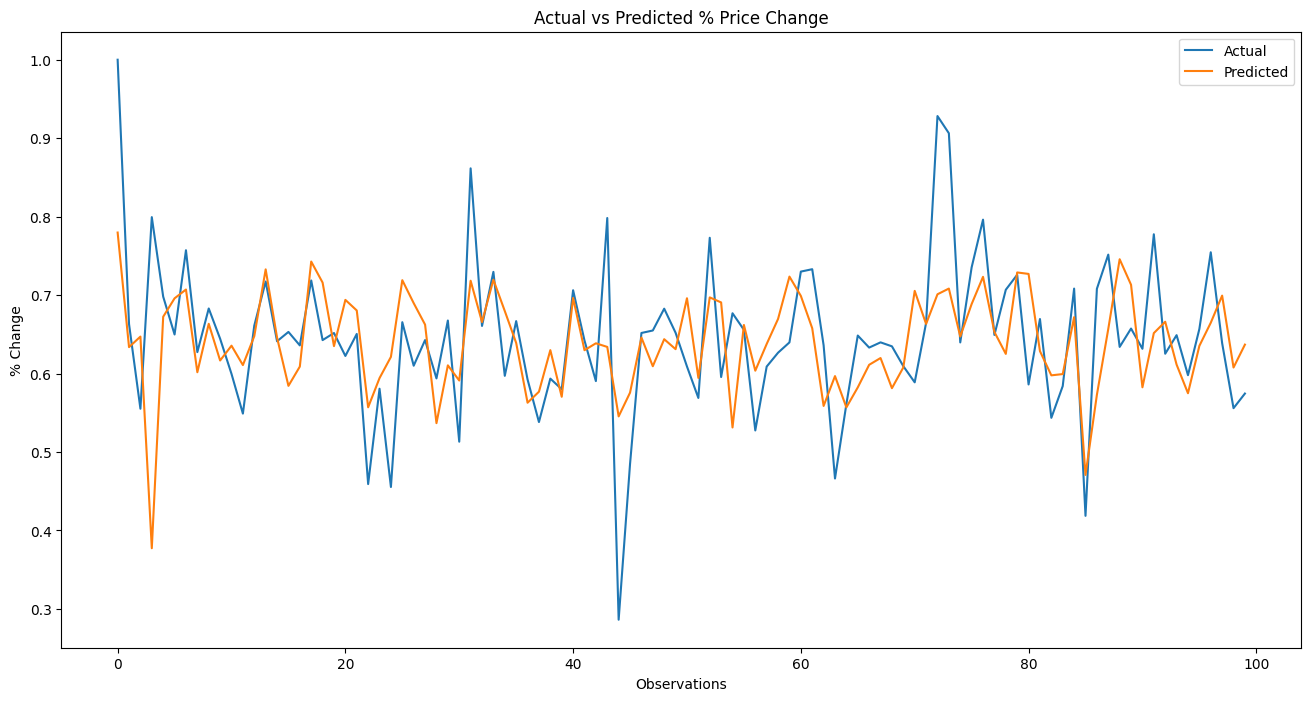

In [7]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

y_pred = y_pred.flatten()
y_test = y_test.flatten()

plt.figure(figsize=(16, 8))

plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.title('Actual vs Predicted % Price Change')
plt.xlabel('Observations')
plt.ylabel('% Change')
plt.legend(loc='upper right')
plt.show()

In [37]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

def create_model(lstm_units, dense_units_1, dense_units_2, optimizer):
    model = Sequential()
    model.add(LSTM(lstm_units, input_shape=(1, X_train.shape[2])))
    model.add(Dense(dense_units_1, activation='relu'))
    model.add(Dense(dense_units_2, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=optimizer, metrics=['mean_absolute_error'])
    return model

# Assuming X_train, y_train, scaler, y_scaler are already defined from previous cells

best_loss = 1e9
best_params = None

# Define parameter grid
param_grid = {
    'lstm_units': [32, 64, 128],
    'dense_units_1': [16, 32, 64],
    'dense_units_2': [16, 32, 64],
    'optimizer': ['adam', 'rmsprop']
}

for lstm_u in param_grid['lstm_units']:
    for d1_u in param_grid['dense_units_1']:
        for d2_u in param_grid['dense_units_2']:
            for opt in param_grid['optimizer']:
                print(f"Training with LSTM units: {lstm_u}, Dense1 units: {d1_u}, Dense2 units: {d2_u}, Optimizer: {opt}")
                model = create_model(lstm_u, d1_u, d2_u, opt)
                history = model.fit(X_train, y_train, epochs=50, batch_size=20, verbose=0)
                loss = history.history["loss"][-1]

                if loss < best_loss:
                    best_loss = loss
                    best_params = (lstm_u, d1_u, d2_u, opt)

print("Best Loss:", best_loss)
print("Best Parameters:", best_params)


Training with LSTM units: 32, Dense1 units: 16, Dense2 units: 16, Optimizer: adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with LSTM units: 32, Dense1 units: 16, Dense2 units: 16, Optimizer: rmsprop
Training with LSTM units: 32, Dense1 units: 16, Dense2 units: 32, Optimizer: adam
Training with LSTM units: 32, Dense1 units: 16, Dense2 units: 32, Optimizer: rmsprop
Training with LSTM units: 32, Dense1 units: 16, Dense2 units: 64, Optimizer: adam
Training with LSTM units: 32, Dense1 units: 16, Dense2 units: 64, Optimizer: rmsprop
Training with LSTM units: 32, Dense1 units: 32, Dense2 units: 16, Optimizer: adam
Training with LSTM units: 32, Dense1 units: 32, Dense2 units: 16, Optimizer: rmsprop
Training with LSTM units: 32, Dense1 units: 32, Dense2 units: 32, Optimizer: adam
Training with LSTM units: 32, Dense1 units: 32, Dense2 units: 32, Optimizer: rmsprop
Training with LSTM units: 32, Dense1 units: 32, Dense2 units: 64, Optimizer: adam
Training with LSTM units: 32, Dense1 units: 32, Dense2 units: 64, Optimizer: rmsprop
Training with LSTM units: 32, Dense1 units: 64, Dense2 units: 16, Optimizer: ada

In [40]:
from keras.optimizers import SGD

# Define the model
model = Sequential()
model.add(LSTM(150, input_shape=(1, X_train.shape[2])))
model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

sgd = SGD(learning_rate=0.01)

# Compile the model
model.compile(loss='mse', optimizer=sgd, metrics=['mse'])

# Fit the model to the training data
model.fit(X_train, y_train, epochs=200, batch_size=80, verbose=1)

# Evaluate the model on the test data
score = model.evaluate(X_test, y_test, batch_size=16, verbose=1)
print('Test score:', score)

# Use the model to make predictions on new data
# X_new must have the same number of features (3) as X used for training
X_new = np.array([[0.2, 0.3, 0.4]]) # Changed to 3 features
X_new = scaler.transform(X_new)
X_new = np.reshape(X_new, (X_new.shape[0], 1, X_new.shape[1]))
y_pred = model.predict(X_new)
y_pred = y_scaler.inverse_transform(y_pred)
print('Predicted changes in price after 1 day:', y_pred)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3947 - mse: 0.3947  
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2809 - mse: 0.2809 
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2064 - mse: 0.2064 
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1548 - mse: 0.1548 
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1099 - mse: 0.1099 
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0826 - mse: 0.0826 
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0621 - mse: 0.0621 
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0459 - mse: 0.0459
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0352 - mse: 0.0352 
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0275 - mse: 0.0275 
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0210 - mse: 0.0210 
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0180 - mse: 0.0180 
Epoch 13/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Predicted changes in price after 1 day: [[0.7891846]]


In [41]:
from tensorflow.keras.callbacks import EarlyStopping

# Use the best parameters found during hyperparameter tuning
# best_params = (128, 16, 32, 'adam') from previous cell
model = create_model(lstm_units=best_params[0], dense_units_1=best_params[1], dense_units_2=best_params[2], optimizer=best_params[3])

history = model.fit(
    X_train, y_train,
    epochs=500,
    batch_size=36,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=1
)

# Reshape y_test back to 2D for evaluation, as it was flattened for plotting previously
loss = model.evaluate(X_test, y_test.reshape(-1, 1))
print("Test MSE:", loss)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.3775 - mean_absolute_error: 0.6095 - val_loss: 0.2771 - val_mean_absolute_error: 0.5140
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2531 - mean_absolute_error: 0.4944 - val_loss: 0.1434 - val_mean_absolute_error: 0.3685
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1199 - mean_absolute_error: 0.3317 - val_loss: 0.0328 - val_mean_absolute_error: 0.1654
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0183 - mean_absolute_error: 0.1137 - val_loss: 0.0163 - val_mean_absolute_error: 0.0929
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0169 - mean_absolute_error: 0.1014 - val_loss: 0.0177 - val_mean_absolute_error: 0.0984
Epoch 6/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0109 - mean_absolute_error: 0.0816 - val_loss: 0.0109 - val_mean_absolute_error: 0.0670
Epoch 7/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0081 - mean_absolute_error: 0.0724 - val_loss: 0.0117 - val_mean

Training fold 1...
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.3700 - mean_absolute_error: 0.6008 - val_loss: 0.2450 - val_mean_absolute_error: 0.4850
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2098 - mean_absolute_error: 0.4468 - val_loss: 0.0832 - val_mean_absolute_error: 0.2766
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0555 - mean_absolute_error: 0.2133 - val_loss: 0.0096 - val_mean_absolute_error: 0.0705
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0123 - mean_absolute_error: 0.0838 - val_loss: 0.0243 - val_mean_absolute_error: 0.1279
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0136 - mean_absolute_error: 0.0954 - val_loss: 0.0090 - val_mean_absolute_error: 0.0673
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0074 - mean_absolute_error: 0.0629 - val_loss: 0.0102 - val_mean_absolute_error: 0.0750
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0080 - mean_absolute_error: 0.0710 - val_loss: 0.0089 - val_mean

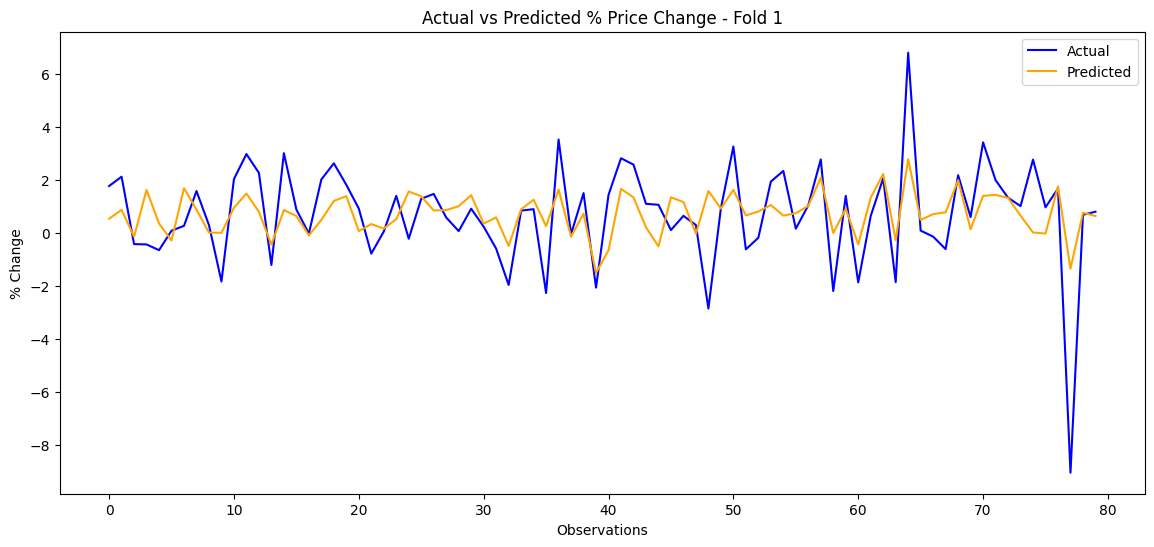

Training fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.3921 - mean_absolute_error: 0.6205 - val_loss: 0.3221 - val_mean_absolute_error: 0.5568
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3018 - mean_absolute_error: 0.5413 - val_loss: 0.2032 - val_mean_absolute_error: 0.4401
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1733 - mean_absolute_error: 0.4065 - val_loss: 0.0746 - val_mean_absolute_error: 0.2585
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0485 - mean_absolute_error: 0.2005 - val_loss: 0.0106 - val_mean_absolute_error: 0.0750
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0099 - mean_absolute_error: 0.0767 - val_loss: 0.0225 - val_mean_absolute_error: 0.1189
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0170 - mean_absolute_error: 0.1017 - val_loss: 0.0107 - val_mean_absolute_error: 0.0737
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0063 - mean_absolute_error: 0.0590 - val_loss: 0.011

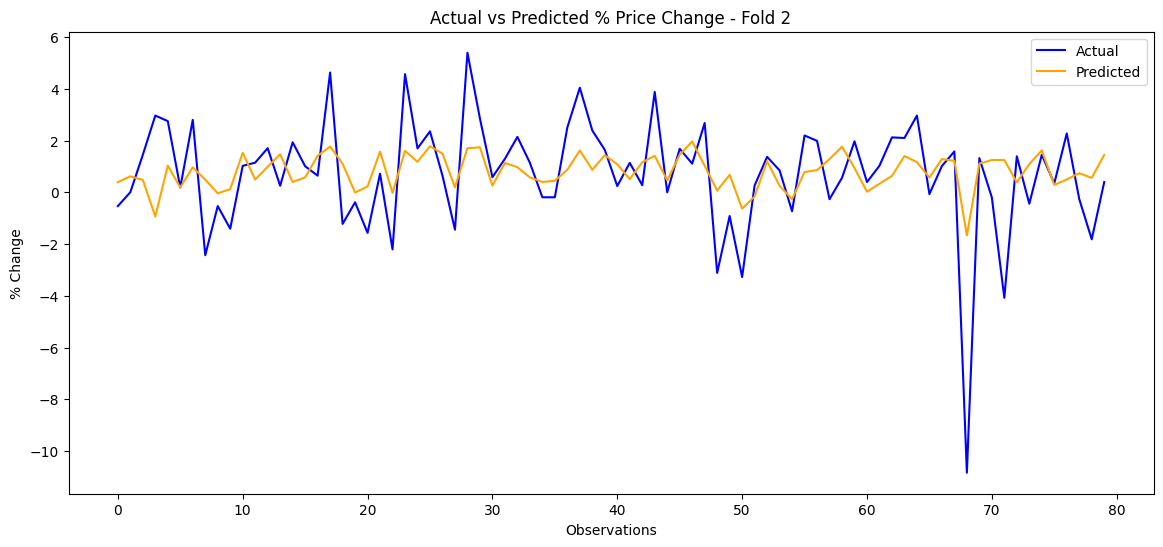

Training fold 3...
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.3710 - mean_absolute_error: 0.6018 - val_loss: 0.2648 - val_mean_absolute_error: 0.5100
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2198 - mean_absolute_error: 0.4572 - val_loss: 0.0975 - val_mean_absolute_error: 0.3056
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0641 - mean_absolute_error: 0.2326 - val_loss: 0.0044 - val_mean_absolute_error: 0.0540
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0146 - mean_absolute_error: 0.0914 - val_loss: 0.0174 - val_mean_absolute_error: 0.1161
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0185 - mean_absolute_error: 0.1084 - val_loss: 0.0044 - val_mean_absolute_error: 0.0543
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0087 - mean_absolute_error: 0.0709 - val_loss: 0.0070 - val_mean_absolute_error: 0.0683
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0098 - mean_absolute_error: 0.0769 - val_loss: 0.0043 - val_mean

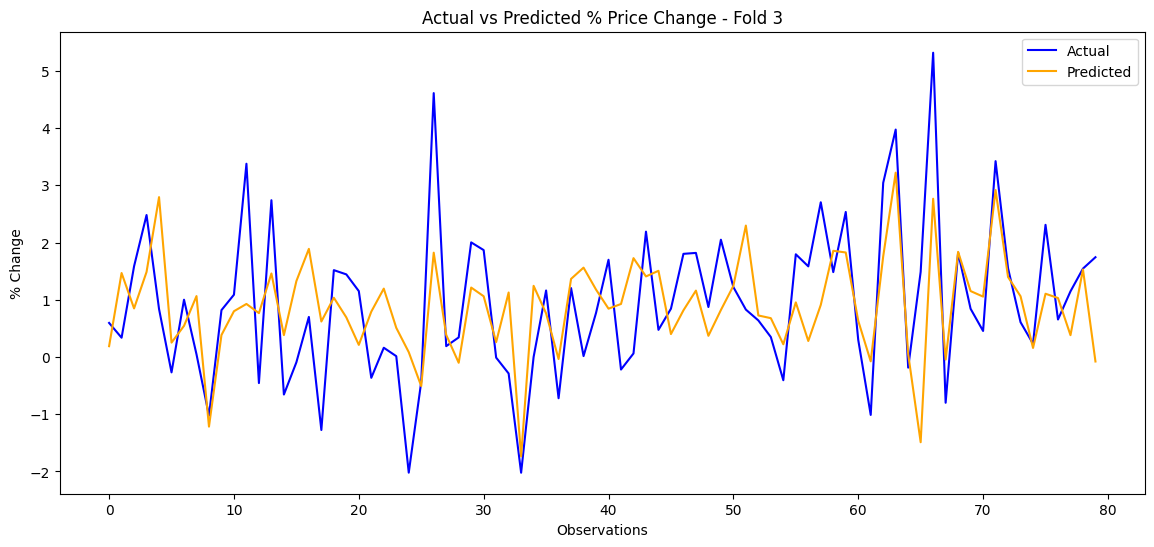

Training fold 4...
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.3690 - mean_absolute_error: 0.6000 - val_loss: 0.2863 - val_mean_absolute_error: 0.5270
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2429 - mean_absolute_error: 0.4839 - val_loss: 0.1488 - val_mean_absolute_error: 0.3750
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1063 - mean_absolute_error: 0.3133 - val_loss: 0.0337 - val_mean_absolute_error: 0.1653
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0168 - mean_absolute_error: 0.1081 - val_loss: 0.0117 - val_mean_absolute_error: 0.0852
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0173 - mean_absolute_error: 0.1012 - val_loss: 0.0120 - val_mean_absolute_error: 0.0870
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0130 - mean_absolute_error: 0.0835 - val_loss: 0.0094 - val_mean_absolute_error: 0.0705
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0071 - mean_absolute_error: 0.0649 - val_loss: 0.0105 - val_mean

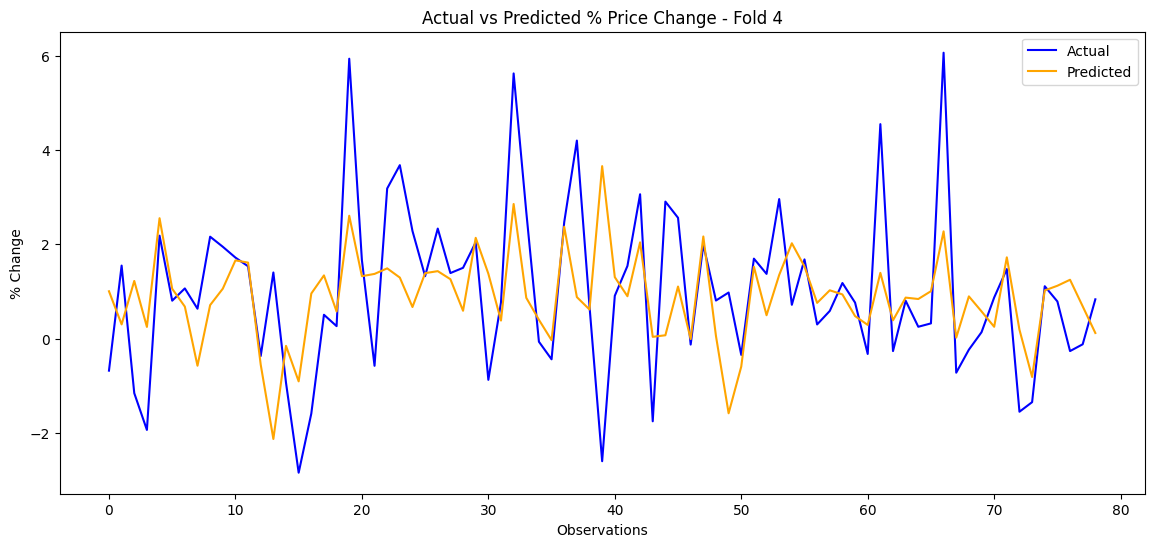

Training fold 5...
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.3753 - mean_absolute_error: 0.6041 - val_loss: 0.2575 - val_mean_absolute_error: 0.5022
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2317 - mean_absolute_error: 0.4704 - val_loss: 0.1079 - val_mean_absolute_error: 0.3201
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0854 - mean_absolute_error: 0.2719 - val_loss: 0.0098 - val_mean_absolute_error: 0.0837
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0127 - mean_absolute_error: 0.0861 - val_loss: 0.0243 - val_mean_absolute_error: 0.1274
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0184 - mean_absolute_error: 0.1096 - val_loss: 0.0084 - val_mean_absolute_error: 0.0685
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0093 - mean_absolute_error: 0.0697 - val_loss: 0.0080 - val_mean_absolute_error: 0.0749
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - mean_absolute_error: 0.0748 - val_loss: 0.0070 - val_mean

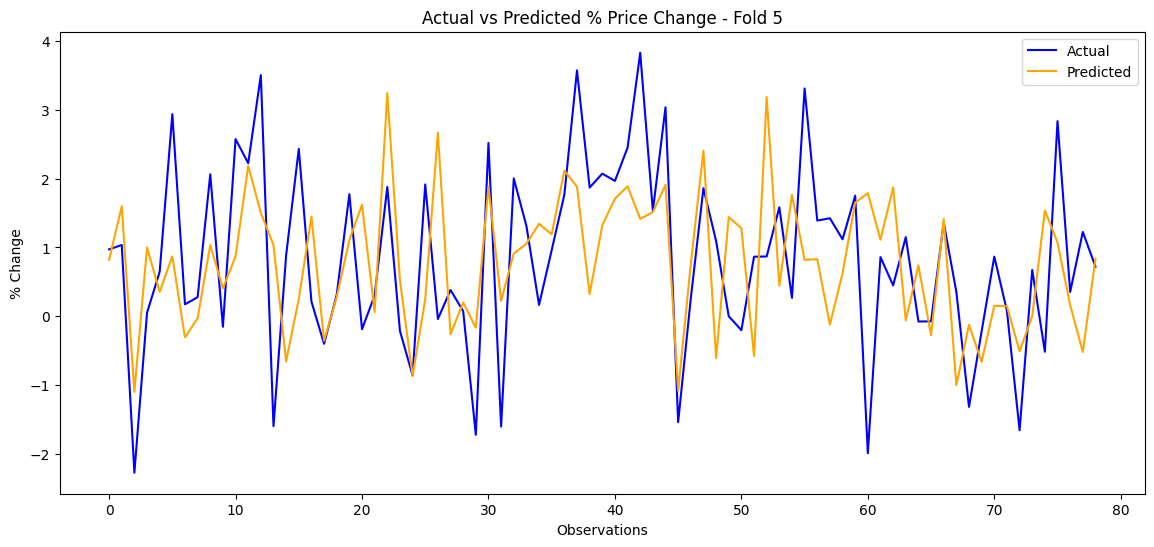

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping

# Performing K-Fold Cross-Validation for robust model evaluation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

early_stop = EarlyStopping(patience=20, restore_best_weights=True)

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train), 1):
    print(f"Training fold {fold_no}...")

    model = create_model(lstm_units=best_params[0], dense_units_1=best_params[1], dense_units_2=best_params[2], optimizer=best_params[3])

    model.fit(
        X_train[train_idx], y_train[train_idx],
        validation_data=(X_train[val_idx], y_train[val_idx]),
        epochs=200,
        batch_size=36,
        verbose=1,
        callbacks=[early_stop]
    )

    y_pred = model.predict(X_train[val_idx])

    y_pred = y_scaler.inverse_transform(y_pred).flatten()
    y_actual = y_scaler.inverse_transform(y_train[val_idx]).flatten()

    plt.figure(figsize=(14,6))
    plt.plot(y_actual, label='Actual', color='blue')
    plt.plot(y_pred, label='Predicted', color='orange')
    plt.title(f'Actual vs Predicted % Price Change - Fold {fold_no}')
    plt.xlabel('Observations')
    plt.ylabel('% Change')
    plt.legend()
    plt.show()